In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("../data/raw_data/trees_indian_dataset.csv")
df.head(3)

,Count,State_Province,City,Latitude,Longitude,Elevation,Tree_Name,Tree_Age,Height_Meter,Trunk_Diameter_cm,...,Watering_Frequency,Fertilizer_Usage,Pruning_Count,Treatment_History,Inspection_Frequency,Tree_Health_Status,Growth_Rate_m_per_year,Expected_Total_Lifespan_Years,Carbon_Absorption_kg,Survival_Probability
0,1,Gujarat,Ahmedabad,23.017811,72.567292,53,Gulmohar,78,20.71,51.77,...,Weekly,Organic Compost,1,No History,Quarterly,Excellent,0.306,95,79.97,0.96
1,2,Punjab,Ludhiana,30.902437,75.867032,247,Bael,70,17.82,44.54,...,Weekly,Organic Compost,1,No History,Quarterly,Excellent,0.581,95,68.83,1.00
2,3,Delhi,Delhi,28.621786,77.199431,217,Haritaki,94,19.49,48.72,...,Weekly,Organic Compost,1,No History,Quarterly,Excellent,0.405,95,74.39,0.99


In [3]:
df.shape

(20000, 49)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 49 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Count                          20000 non-null  int64  
 1   State_Province                 20000 non-null  str    
 2   City                           20000 non-null  str    
 3   Latitude                       20000 non-null  float64
 4   Longitude                      20000 non-null  float64
 5   Elevation                      20000 non-null  int64  
 6   Tree_Name                      20000 non-null  str    
 7   Tree_Age                       20000 non-null  int64  
 8   Height_Meter                   20000 non-null  float64
 9   Trunk_Diameter_cm              20000 non-null  float64
 10  Canopy_Width_m                 20000 non-null  float64
 11  Root_Depth_m                   20000 non-null  float64
 12  Growth_Stage                   20000 non-null  str    
 1

In [7]:
df.describe()

,Count,Latitude,Longitude,Elevation,Tree_Age,Height_Meter,Trunk_Diameter_cm,Canopy_Width_m,Root_Depth_m,Temperature_C,...,Phosphorus,Potassium,Organic_Carbon,Leaf_Drop_Percentage,Water_Stress_Index,Pruning_Count,Growth_Rate_m_per_year,Expected_Total_Lifespan_Years,Carbon_Absorption_kg,Survival_Probability
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.00000,20000.000000,20000.00000,20000.000000,20000.000000
mean,10000.500000,23.526521,82.607181,517.592750,59.780050,17.667278,44.168134,12.230683,7.155201,30.431505,...,30.092735,179.393045,1.328981,19.35650,0.317557,0.91570,0.389577,103.15380,67.994425,0.852197
std,5773.647028,5.607160,6.981514,603.348554,34.328026,4.134568,10.336432,2.862131,1.674502,8.964782,...,12.706398,74.818755,0.675681,18.60568,0.238496,0.68638,0.142507,36.15974,14.746753,0.178391
min,1.000000,9.921204,72.561411,-3.000000,1.000000,2.870000,7.190000,1.990000,1.160000,15.000000,...,8.000000,50.000000,0.150000,0.00000,0.010000,0.00000,0.005000,40.00000,11.210000,0.260000
25%,5000.750000,20.299807,77.030604,45.000000,30.000000,15.660000,39.160000,10.840000,6.340000,22.700000,...,19.200000,114.275000,0.740000,6.00000,0.130000,0.00000,0.288000,95.00000,60.837500,0.730000
50%,10000.500000,24.807418,80.940476,293.000000,60.000000,18.700000,46.740000,12.950000,7.570000,30.400000,...,30.200000,179.450000,1.330000,12.00000,0.250000,1.00000,0.397000,95.00000,71.670000,0.960000
75%,15000.250000,27.082781,88.616652,786.000000,90.000000,20.590000,51.472500,14.250000,8.340000,38.200000,...,41.100000,243.500000,1.910000,30.00000,0.480000,1.00000,0.497000,95.00000,78.540000,0.990000
max,20000.000000,34.093656,94.118579,2210.000000,119.000000,24.220000,60.540000,16.770000,9.810000,46.000000,...,52.000000,310.000000,2.500000,87.00000,0.990000,2.00000,0.650000,250.00000,88.000000,1.000000


In [6]:
df.isnull().sum()

Count                            0
State_Province                   0
City                             0
Latitude                         0
Longitude                        0
Elevation                        0
Tree_Name                        0
Tree_Age                         0
Height_Meter                     0
Trunk_Diameter_cm                0
Canopy_Width_m                   0
Root_Depth_m                     0
Growth_Stage                     0
Temperature_C                    0
Rainfall_mm                      0
Humidity_Pct                     0
Wind_Speed_kmh                   0
Solar_Radiation_W_m2             0
Drought_Index                    0
AQI                              0
PM2_5                            0
PM10                             0
CO_Level                         0
NO2_Level                        0
SO2_Level                        0
Soil_Type                        0
Soil_pH                          0
Nitrogen                         0
Phosphorus          

In [8]:
df.duplicated().sum()

np.int64(0)

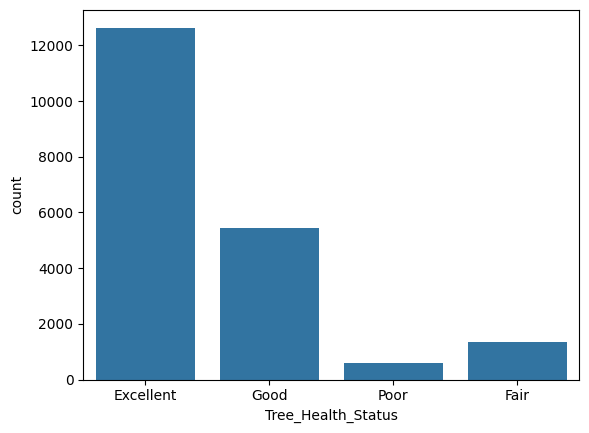

In [9]:
# Health Status Distribution
sns.countplot(
    x="Tree_Health_Status",
    data=df
)
plt.show()


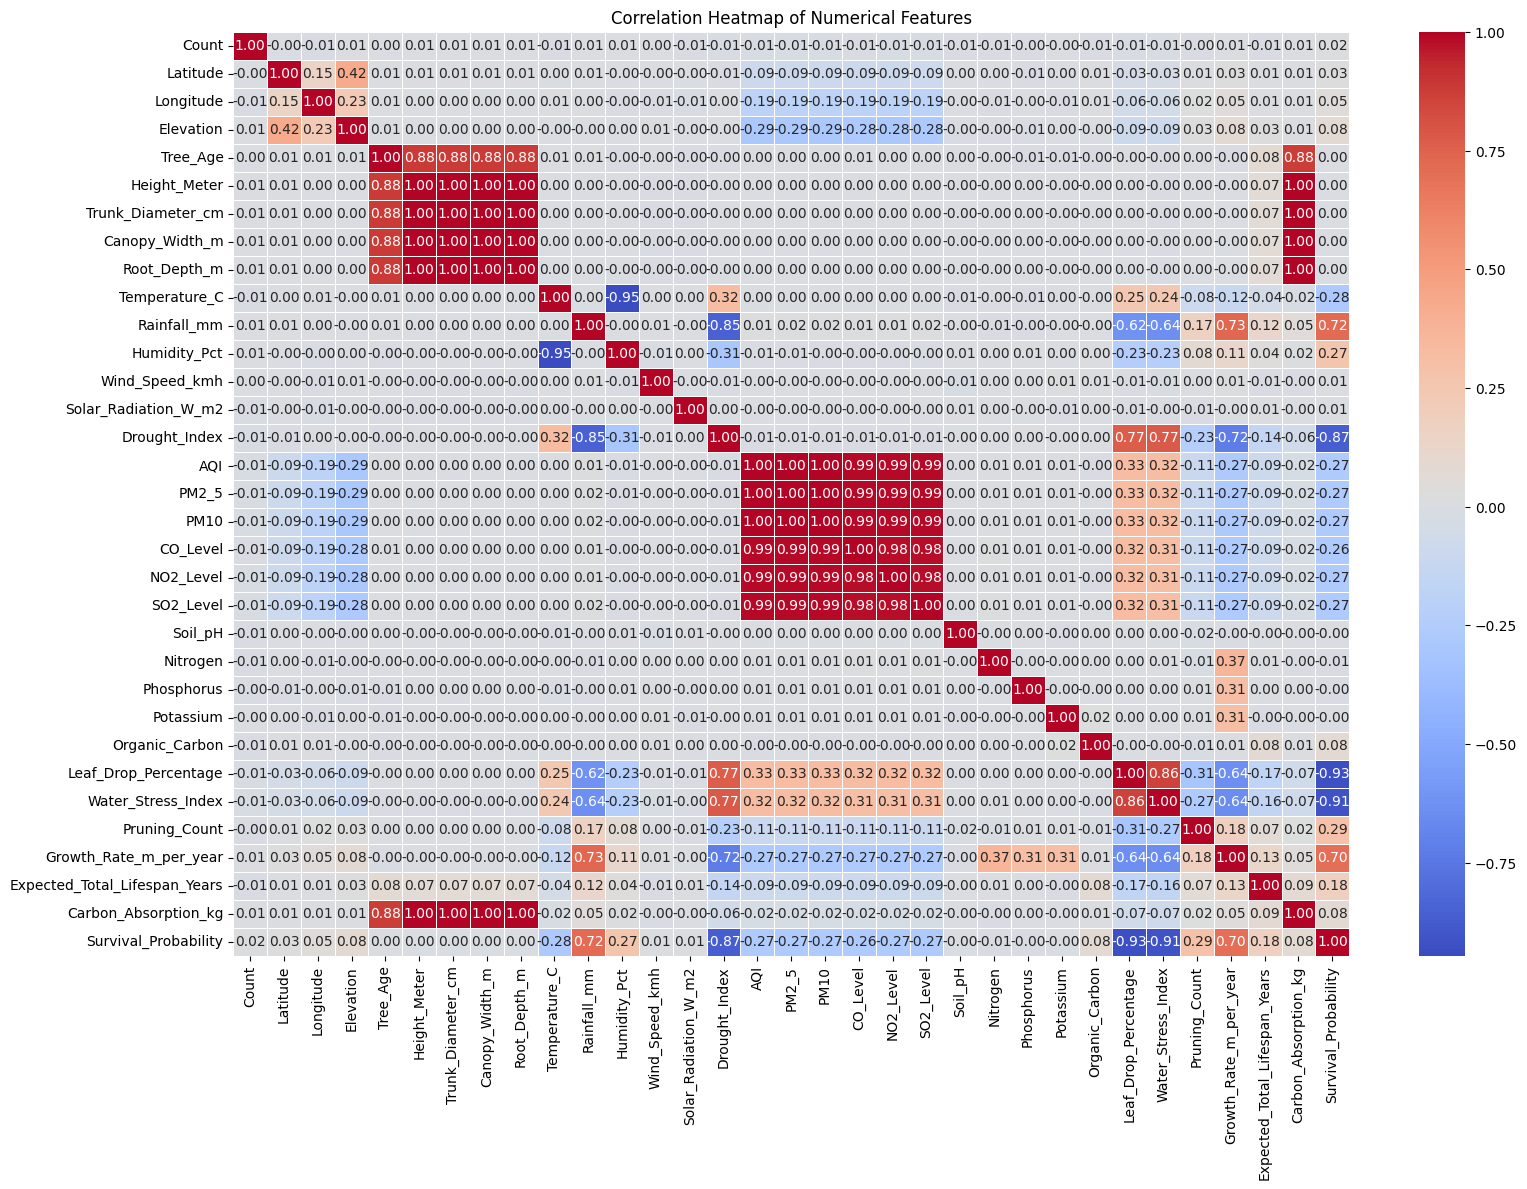

In [10]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(18, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

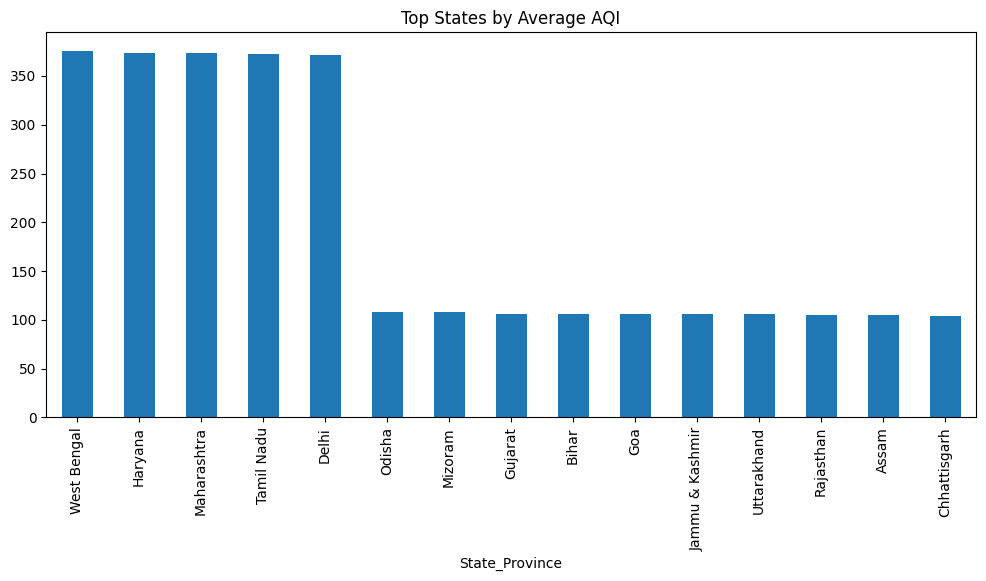

In [13]:
state_aqi = df.groupby(
    "State_Province"
)["AQI"].mean().sort_values(
    ascending=False
)

plt.figure(figsize=(12,5))

state_aqi.head(15).plot(
    kind="bar"
)

plt.title("Top States by Average AQI")

plt.show()

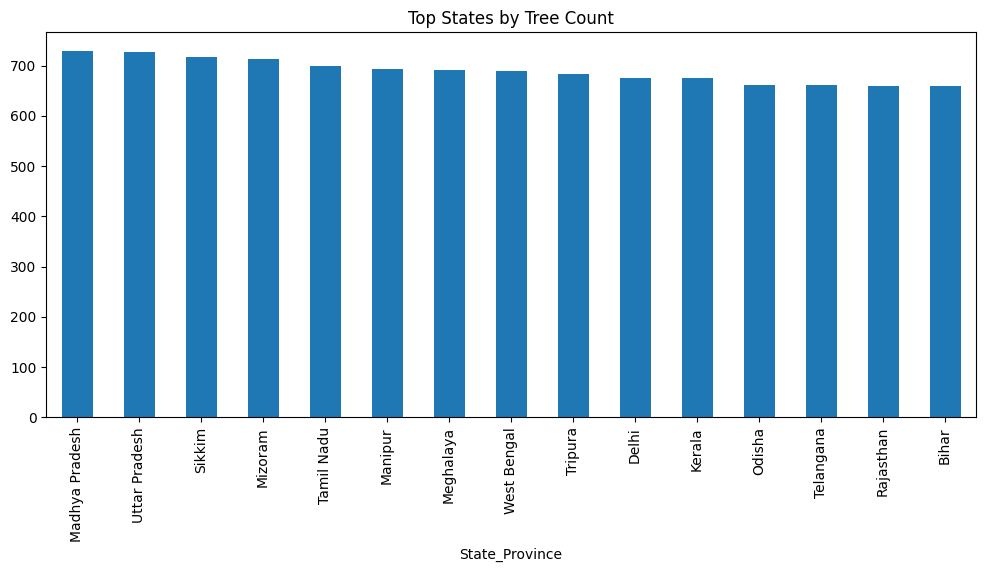

In [14]:
state_count = df["State_Province"].value_counts()

plt.figure(figsize=(12,5))

state_count.head(15).plot(
    kind="bar"
)

plt.title("Top States by Tree Count")

plt.show()

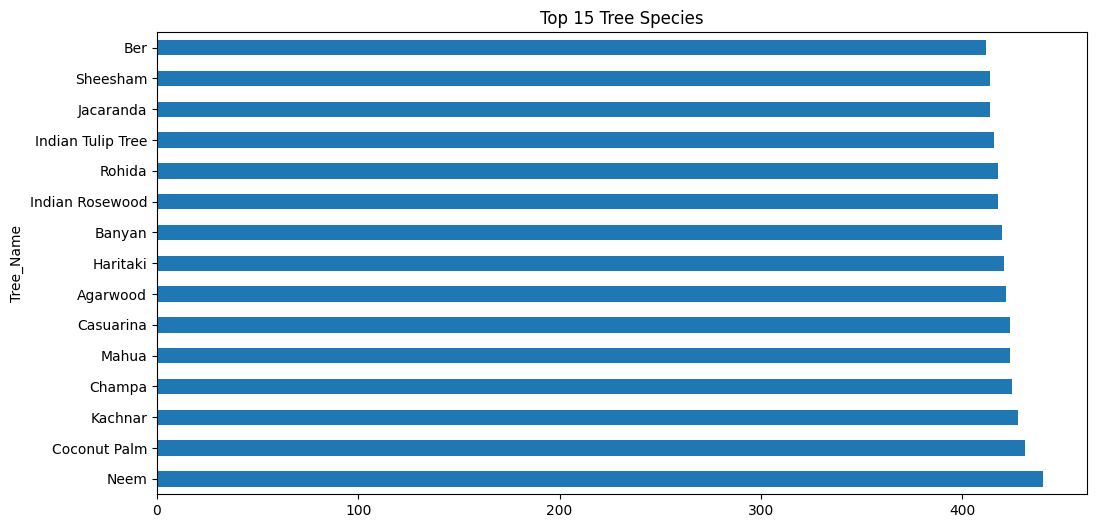

In [17]:
plt.figure(figsize=(12,6))

df["Tree_Name"].value_counts().head(15).plot(
    kind='barh'
)

plt.title("Top 15 Tree Species")

plt.show()

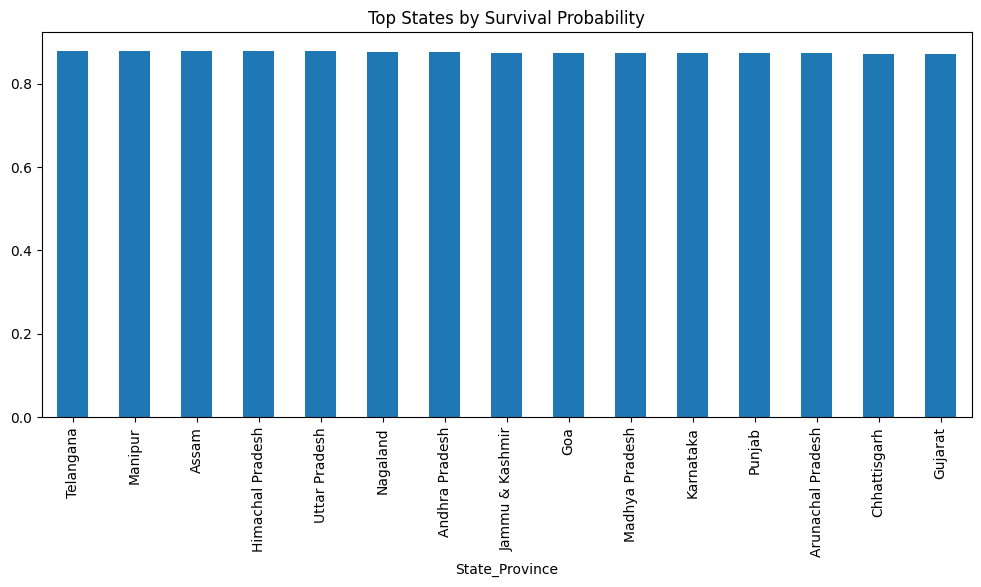

In [16]:
state_survival = df.groupby(
    "State_Province"
)["Survival_Probability"].mean()

plt.figure(figsize=(12,5))

state_survival.sort_values(
    ascending=False
).head(15).plot(
    kind="bar"
)

plt.title("Top States by Survival Probability")

plt.show()